In [5]:
import pandas as pd

thyroid = pd.read_csv("../datasets/thyroid.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../datasets/thyroid.csv'

In [6]:
import os

print(os.listdir("../datasets"))

['.ipynb_checkpoints', 'anemia.csv', 'diabetes.csv', 'FedCycleData071012 (2).csv', 'healthcare-dataset-stroke-data.csv', 'PCOS_data_without_infertility.xlsx', 'PCOS_infertility.csv', 'Pregnecy_complication_dataset.csv', 'thyroid_cancer_risk_data.csv']


In [7]:
import pandas as pd

thyroid = pd.read_csv("../datasets/thyroid_cancer_risk_data.csv")

In [8]:
thyroid.head()

,Patient_ID,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Diagnosis
0,1,66,Male,Russia,Caucasian,No,Yes,No,No,No,No,9.37,1.67,6.16,1.08,Low,Benign
1,2,29,Male,Germany,Hispanic,No,Yes,No,No,No,No,1.83,1.73,10.54,4.05,Low,Benign
2,3,86,Male,Nigeria,Caucasian,No,No,No,No,No,No,6.26,2.59,10.57,4.61,Low,Benign
3,4,75,Female,India,Asian,No,No,No,No,No,No,4.10,2.62,11.04,2.46,Medium,Benign
4,5,35,Female,Germany,African,Yes,Yes,No,No,No,No,9.10,2.11,10.71,2.11,High,Benign


In [9]:
thyroid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212691 entries, 0 to 212690
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Patient_ID           212691 non-null  int64  
 1   Age                  212691 non-null  int64  
 2   Gender               212691 non-null  object 
 3   Country              212691 non-null  object 
 4   Ethnicity            212691 non-null  object 
 5   Family_History       212691 non-null  object 
 6   Radiation_Exposure   212691 non-null  object 
 7   Iodine_Deficiency    212691 non-null  object 
 8   Smoking              212691 non-null  object 
 9   Obesity              212691 non-null  object 
 10  Diabetes             212691 non-null  object 
 11  TSH_Level            212691 non-null  float64
 12  T3_Level             212691 non-null  float64
 13  T4_Level             212691 non-null  float64
 14  Nodule_Size          212691 non-null  float64
 15  Thyroid_Cancer_Ri

In [10]:
thyroid.columns.tolist()

['Patient_ID',
 'Age',
 'Gender',
 'Country',
 'Ethnicity',
 'Family_History',
 'Radiation_Exposure',
 'Iodine_Deficiency',
 'Smoking',
 'Obesity',
 'Diabetes',
 'TSH_Level',
 'T3_Level',
 'T4_Level',
 'Nodule_Size',
 'Thyroid_Cancer_Risk',
 'Diagnosis']

In [11]:
print(thyroid["Diagnosis"].unique())

['Benign' 'Malignant']


In [12]:
print(thyroid["Thyroid_Cancer_Risk"].unique())

['Low' 'Medium' 'High']


In [13]:
thyroid.isnull().sum()

Patient_ID             0
Age                    0
Gender                 0
Country                0
Ethnicity              0
Family_History         0
Radiation_Exposure     0
Iodine_Deficiency      0
Smoking                0
Obesity                0
Diabetes               0
TSH_Level              0
T3_Level               0
T4_Level               0
Nodule_Size            0
Thyroid_Cancer_Risk    0
Diagnosis              0
dtype: int64

In [14]:
thyroid.dtypes

Patient_ID               int64
Age                      int64
Gender                  object
Country                 object
Ethnicity               object
Family_History          object
Radiation_Exposure      object
Iodine_Deficiency       object
Smoking                 object
Obesity                 object
Diabetes                object
TSH_Level              float64
T3_Level               float64
T4_Level               float64
Nodule_Size            float64
Thyroid_Cancer_Risk     object
Diagnosis               object
dtype: object

In [15]:
thyroid = thyroid.drop(columns=["Patient_ID"])

In [16]:
thyroid["Diagnosis"] = thyroid["Diagnosis"].map({
    "Benign": 0,
    "Malignant": 1
})

In [17]:
thyroid = pd.get_dummies(
    thyroid,
    columns=[
        "Gender",
        "Country",
        "Ethnicity",
        "Family_History",
        "Radiation_Exposure",
        "Iodine_Deficiency",
        "Smoking",
        "Obesity",
        "Diabetes",
        "Thyroid_Cancer_Risk"
    ],
    drop_first=True
)

In [18]:
X = thyroid.drop(columns=["Diagnosis"])
y = thyroid["Diagnosis"]

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [21]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [22]:
y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8250546557276852


In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[30657  1958]
 [ 5484  4440]]


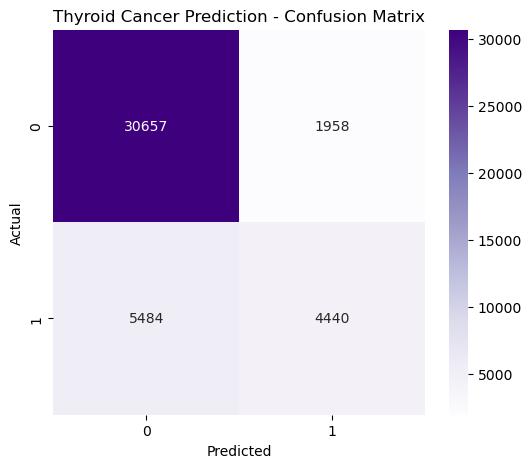

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')

plt.title("Thyroid Cancer Prediction - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.94      0.89     32615
           1       0.69      0.45      0.54      9924

    accuracy                           0.83     42539
   macro avg       0.77      0.69      0.72     42539
weighted avg       0.81      0.83      0.81     42539



In [27]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

importance = importance.sort_values(by="Coefficient", ascending=False)

print(importance.head(15))

                     Feature  Coefficient
13                Country_UK     0.036547
11            Country_Russia     0.035829
17        Ethnicity_Hispanic     0.031426
18  Ethnicity_Middle Eastern     0.027205
10           Country_Nigeria     0.018382
7            Country_Germany     0.013405
16       Ethnicity_Caucasian     0.012792
20    Radiation_Exposure_Yes     0.011715
15           Ethnicity_Asian     0.009738
23               Obesity_Yes     0.009003
12       Country_South Korea     0.008968
22               Smoking_Yes     0.008629
5                Gender_Male     0.006430
0                        Age    -0.000329
9              Country_Japan    -0.000476


In [28]:
import joblib

joblib.dump(model, "thyroid_model.pkl")

print("Thyroid model saved successfully!")

Thyroid model saved successfully!


# Conclusion

The Thyroid Cancer Risk Prediction model was successfully developed using Logistic Regression. The dataset was cleaned and categorical features were encoded using one-hot encoding. The model was trained and evaluated using standard machine learning metrics such as Accuracy, Confusion Matrix, and Classification Report. The trained model was saved for future integration into the Silent Health Risk Detector for Women.

This model forms the fourth prediction module of the project and will be integrated with the PCOS, Anemia, Diabetes, and Stroke prediction models.

In [30]:
print(X.columns.tolist())

['Age', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size', 'Gender_Male', 'Country_China', 'Country_Germany', 'Country_India', 'Country_Japan', 'Country_Nigeria', 'Country_Russia', 'Country_South Korea', 'Country_UK', 'Country_USA', 'Ethnicity_Asian', 'Ethnicity_Caucasian', 'Ethnicity_Hispanic', 'Ethnicity_Middle Eastern', 'Family_History_Yes', 'Radiation_Exposure_Yes', 'Iodine_Deficiency_Yes', 'Smoking_Yes', 'Obesity_Yes', 'Diabetes_Yes', 'Thyroid_Cancer_Risk_Low', 'Thyroid_Cancer_Risk_Medium']


In [31]:
print(X.shape)

(212691, 27)


In [32]:
print(y.unique())

[0 1]


In [33]:
print(X.columns.tolist())

['Age', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size', 'Gender_Male', 'Country_China', 'Country_Germany', 'Country_India', 'Country_Japan', 'Country_Nigeria', 'Country_Russia', 'Country_South Korea', 'Country_UK', 'Country_USA', 'Ethnicity_Asian', 'Ethnicity_Caucasian', 'Ethnicity_Hispanic', 'Ethnicity_Middle Eastern', 'Family_History_Yes', 'Radiation_Exposure_Yes', 'Iodine_Deficiency_Yes', 'Smoking_Yes', 'Obesity_Yes', 'Diabetes_Yes', 'Thyroid_Cancer_Risk_Low', 'Thyroid_Cancer_Risk_Medium']


In [34]:
print(model.feature_names_in_)

['Age' 'TSH_Level' 'T3_Level' 'T4_Level' 'Nodule_Size' 'Gender_Male'
 'Country_China' 'Country_Germany' 'Country_India' 'Country_Japan'
 'Country_Nigeria' 'Country_Russia' 'Country_South Korea' 'Country_UK'
 'Country_USA' 'Ethnicity_Asian' 'Ethnicity_Caucasian'
 'Ethnicity_Hispanic' 'Ethnicity_Middle Eastern' 'Family_History_Yes'
 'Radiation_Exposure_Yes' 'Iodine_Deficiency_Yes' 'Smoking_Yes'
 'Obesity_Yes' 'Diabetes_Yes' 'Thyroid_Cancer_Risk_Low'
 'Thyroid_Cancer_Risk_Medium']
